## Multi-pairs trading strategy following Lee, Leung & Ning (2023) paper
This notebook implements a multi-pair commodity ETF trading strategy based on Lee, Leung & Ning (2023). Six pairs are constructed from four commodity ETFs (CORN, SOYB, WEAT, BAL) using rolling OLS hedge ratios, producing stationary spread series for each pair. Capital is dynamically allocated across pairs at quarterly rebalancing dates using either Mean Reversion Budgeting (MRB) or Mean Reversion Ranking (MRR), which weight pairs by their speed of mean reversion and OU model fit quality. Within each quarter, a simple z-score entry/exit rule is applied to each pair independently, with the portfolio return aggregated by the allocated weights.

In [55]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from itertools import combinations
from src.multipairs import (
    compute_all_spreads,
    compute_performance,
    run_backtest,
)

# Download ETF prices
tickers = ['CORN', 'SOYB', 'WEAT', 'BAL']
raw = yf.download(tickers, start='2010-01-01', end='2024-12-31', auto_adjust=True)

prices = raw['Close'].dropna()
print(prices.shape)
prices.tail()

[*********************100%***********************]  4 of 4 completed

(1387, 4)


Ticker,BAL,CORN,SOYB,WEAT
Date,,,,
2023-07-17,61.0,22.799999,28.299999,32.500000
2023-07-18,61.0,23.840000,28.600000,33.250000
2023-07-19,61.0,24.590000,28.889999,35.549999
2023-07-20,61.0,24.350000,28.860001,35.500000
2023-07-21,61.0,23.959999,28.790001,34.400002


In [56]:
# Define all pairs
pairs = list(combinations(tickers, 2))
print("Pairs:", pairs)

# Compute rolling OLS spreads for all pairs (this will take ~1 minute)
spreads, betas, alphas = compute_all_spreads(prices, pairs, window=126)

# Quick check
for p, s in spreads.items():
    print(f'{p[0]}-{p[1]}: {s.dropna().shape[0]} valid observations, mean={s.mean():.4f}')

Pairs: [('CORN', 'SOYB'), ('CORN', 'WEAT'), ('CORN', 'BAL'), ('SOYB', 'WEAT'), ('SOYB', 'BAL'), ('WEAT', 'BAL')]
Spread computed: CORN-SOYB
Spread computed: CORN-WEAT
Spread computed: CORN-BAL
Spread computed: SOYB-WEAT
Spread computed: SOYB-BAL
Spread computed: WEAT-BAL
CORN-SOYB: 1261 valid observations, mean=0.0191
CORN-WEAT: 1261 valid observations, mean=0.1190
CORN-BAL: 1261 valid observations, mean=0.0246
SOYB-WEAT: 1261 valid observations, mean=0.1104
SOYB-BAL: 1261 valid observations, mean=0.1620
WEAT-BAL: 1261 valid observations, mean=-0.3516


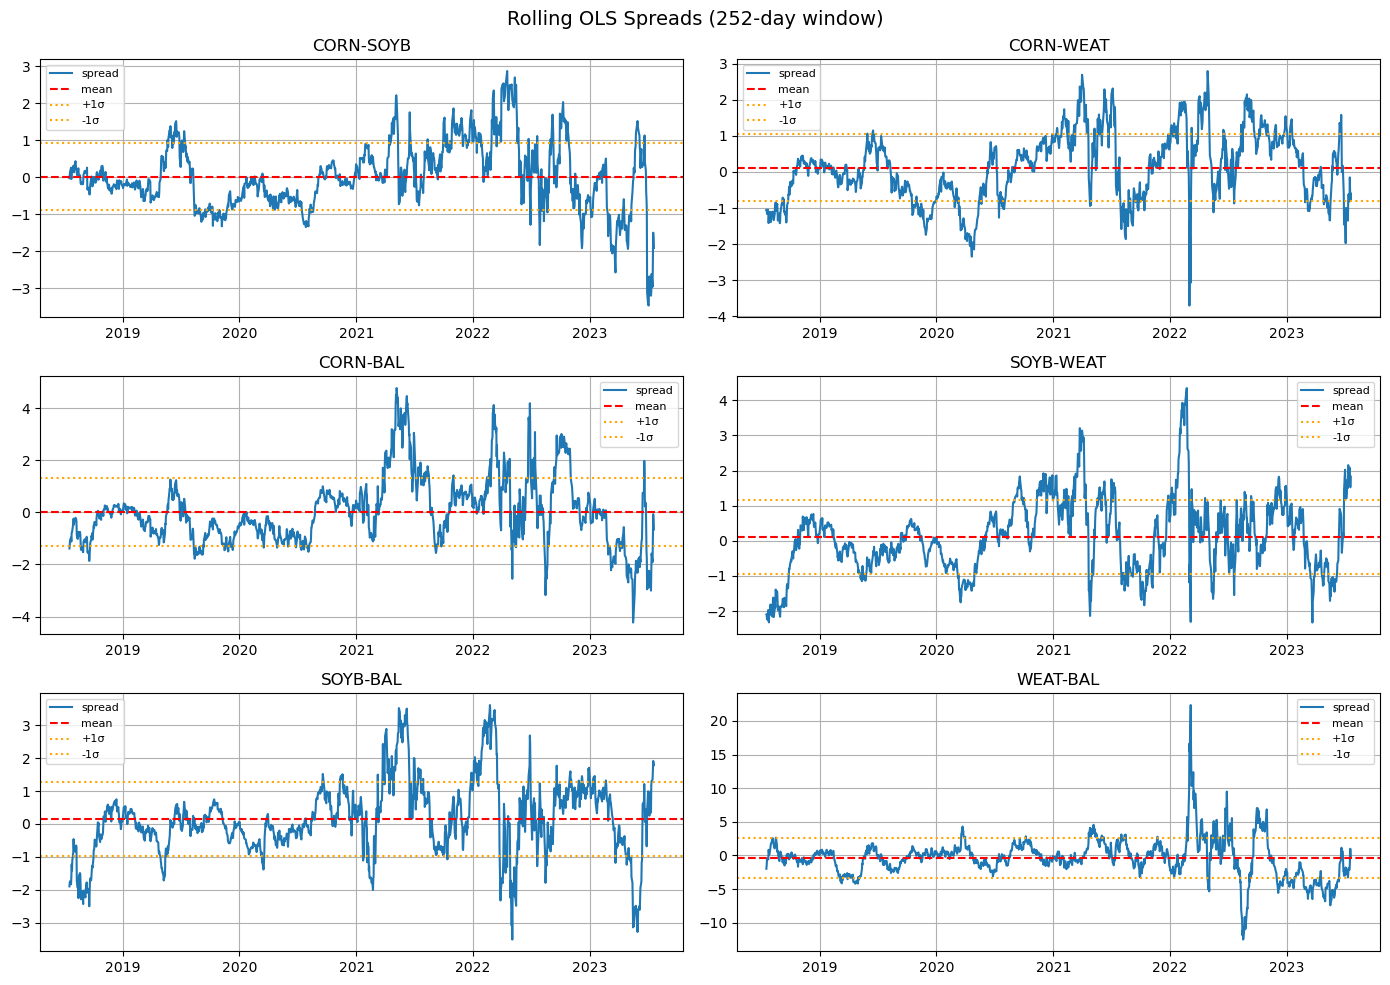

In [57]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (s1, s2) in enumerate(pairs):
    spread = spreads[(s1, s2)].dropna()
    axes[i].plot(spread, label='spread')
    axes[i].axhline(spread.mean(), color='red', linestyle='--', label='mean')
    axes[i].axhline(spread.mean() + spread.std(), color='orange', linestyle=':', label='+1σ')
    axes[i].axhline(spread.mean() - spread.std(), color='orange', linestyle=':', label='-1σ')
    axes[i].set_title(f'{s1}-{s2}')
    axes[i].legend(fontsize=8)
    axes[i].grid(True)

plt.suptitle('Rolling OLS Spreads (252-day window)', fontsize=14)
plt.tight_layout()
plt.show()

In [58]:
import importlib
import src.multipairs as mp
importlib.reload(mp)

# Debug: run EW only and inspect raw returns
returns, weights = mp.run_backtest(
    prices=prices,
    spreads=spreads,
    pairs=pairs,
    K=1.5,
    M=63,
    ols_window=126,
    rebal_freq=21,
    ou_window=63,
    method='EW',
    initial_capital=1.0
)

# Check raw returns
print("Non-zero return days:", (returns != 0).sum())
print("Return stats:")
print(returns[returns != 0].describe())
print("\nFirst 5 non-zero returns:")
print(returns[returns != 0].head())

Non-zero return days: 1083
Return stats:
count    1083.000000
mean        0.018481
std         0.217774
min        -1.047700
25%        -0.083893
50%         0.016331
75%         0.115760
max         1.180716
dtype: float64

First 5 non-zero returns:
Date
2018-10-17   -0.085575
2018-10-18    0.163552
2018-10-19    0.137650
2018-10-22   -0.097009
2018-10-23   -0.089813
dtype: float64


In [63]:
importlib.reload(mp)

for method in ['EW', 'MRB', 'MRR']:
    returns, weights = mp.run_backtest(
        prices=prices, spreads=spreads, pairs=pairs,
        K=1.5, M=63, ols_window=126,
        rebal_freq=21, ou_window=63,
        method=method, initial_capital=1.0
    )
    results[method] = {'returns': returns, 'weights': weights}
    stats = mp.compute_performance(returns)
    print(f'\n{method}:')
    for k, v in stats.items():
        print(f'  {k}: {v}')


EW:
  Ann. Return (normalized): 3.9374
  Ann. Vol (normalized): 2.4373
  Sharpe: 1.6154
  Max Drawdown (normalized): -3.3719
  Final Cumulative P&L: 20.0149

MRB:
  Ann. Return (normalized): 3.579
  Ann. Vol (normalized): 3.932
  Sharpe: 0.9102
  Max Drawdown (normalized): -6.0492
  Final Cumulative P&L: 18.1933

MRR:
  Ann. Return (normalized): 3.8116
  Ann. Vol (normalized): 2.7965
  Sharpe: 1.363
  Max Drawdown (normalized): -3.5669
  Final Cumulative P&L: 19.3755


## Sensitivity tests

=== Sensitivity: K ===
K=0.5 done
K=0.75 done
K=1.0 done
K=1.25 done
K=1.5 done


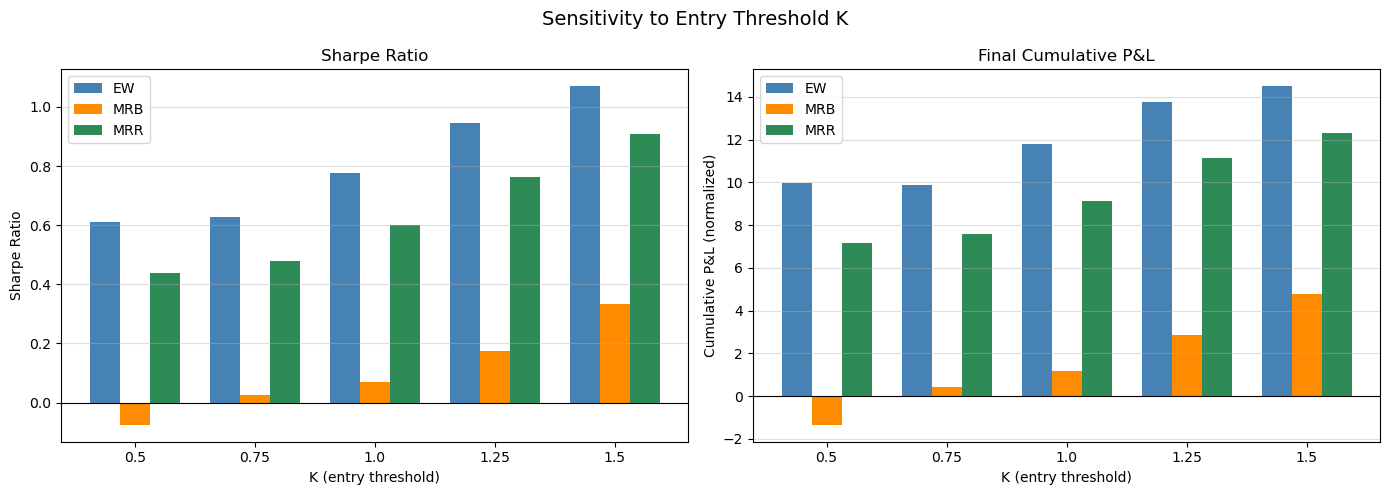


=== Sensitivity: OLS Window ===
Computing spreads for window=126...
Spread computed: CORN-SOYB
Spread computed: CORN-WEAT
Spread computed: CORN-BAL
Spread computed: SOYB-WEAT
Spread computed: SOYB-BAL
Spread computed: WEAT-BAL
Window=126 done
Computing spreads for window=252...
Spread computed: CORN-SOYB
Spread computed: CORN-WEAT
Spread computed: CORN-BAL
Spread computed: SOYB-WEAT
Spread computed: SOYB-BAL
Spread computed: WEAT-BAL
Window=252 done
Computing spreads for window=504...
Spread computed: CORN-SOYB
Spread computed: CORN-WEAT
Spread computed: CORN-BAL
Spread computed: SOYB-WEAT
Spread computed: SOYB-BAL
Spread computed: WEAT-BAL
Window=504 done


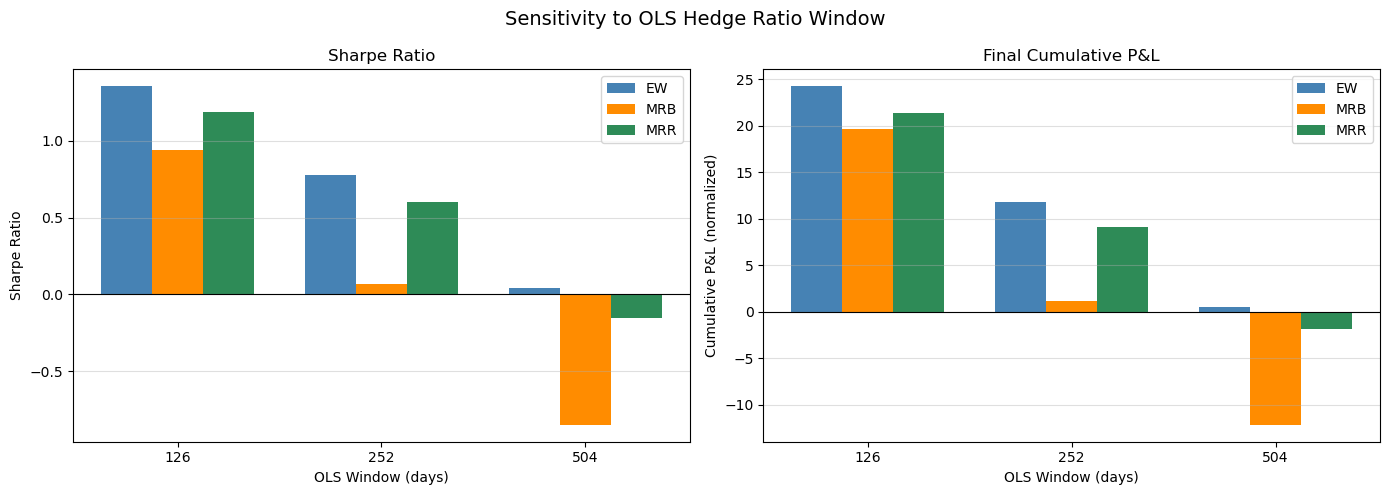


=== Sensitivity: Rebalancing Frequency ===
Rebal=Monthly done
Rebal=Quarterly done
Rebal=Semi-annual done


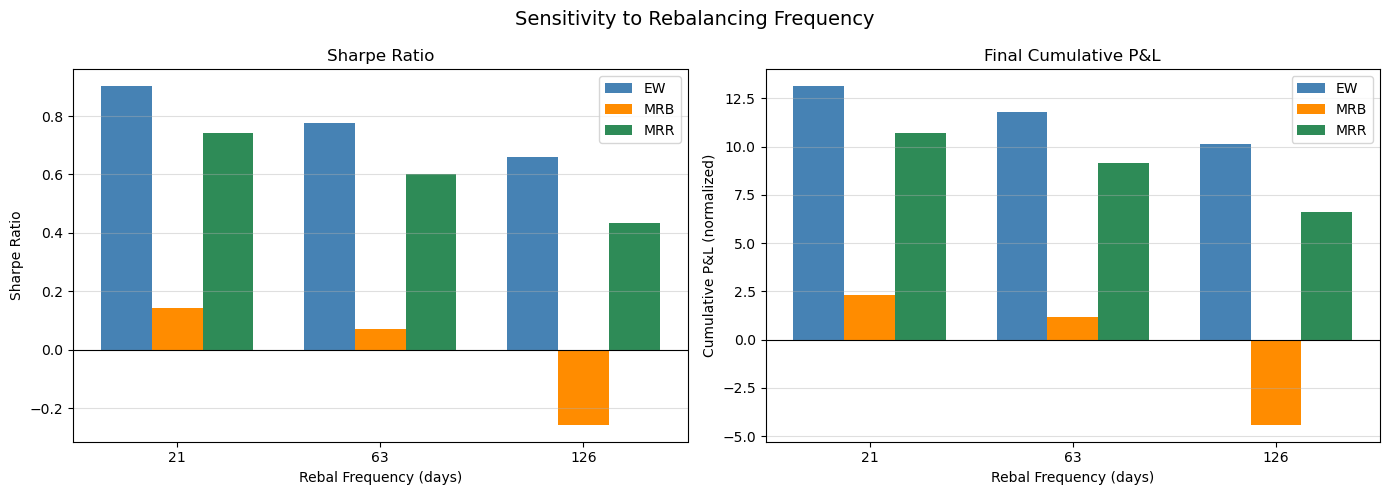


=== Sensitivity: OU Window ===
OU window=63 done
OU window=126 done
OU window=252 done


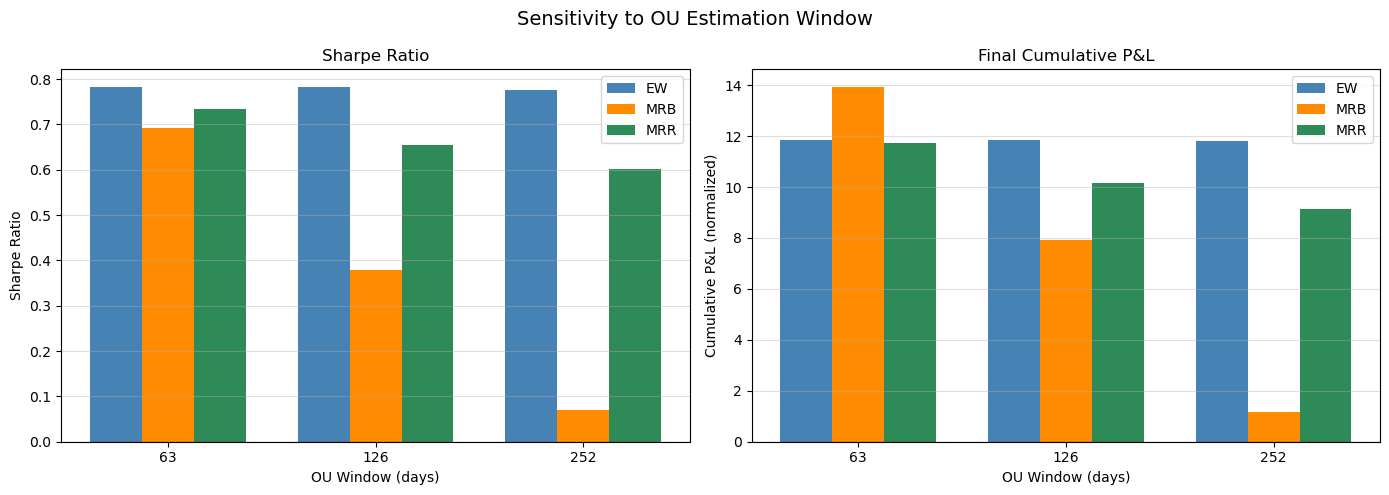

In [38]:
importlib.reload(mp)

all_results = mp.run_sensitivity_all(
    prices=prices,
    spreads=spreads,
    pairs=pairs,
    K=1.0, M=63,
    ols_window=252,
    rebal_freq=63,
    ou_window=252
)

Best hyperparameters:\
K=1.5\
OLS window = 126\
Rebalancing frequency=21(monthly)\
OU window=63

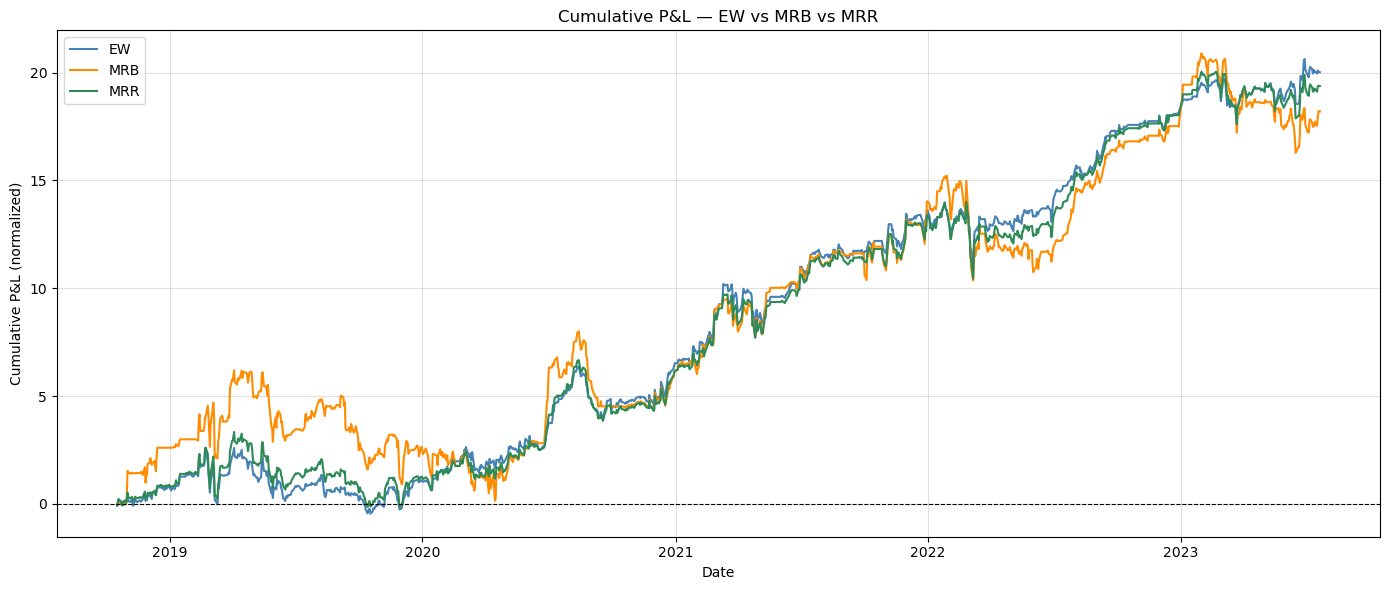

In [64]:
fig, ax = plt.subplots(figsize=(14, 6))

colors = {'EW': 'steelblue', 'MRB': 'darkorange', 'MRR': 'seagreen'}

for method in ['EW', 'MRB', 'MRR']:
    r = results[method]['returns']
    first_trade = r[r != 0].index[0]
    cum = r.loc[first_trade:].cumsum()
    ax.plot(cum, label=method, color=colors[method])

ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_title('Cumulative P&L — EW vs MRB vs MRR')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative P&L (normalized)')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()